**DATA COLLECTION: KSE-100 ANALYSIS**

In [67]:
#IMPORTING ALL THE LIBRARIES NEEDED:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
# We upload the KSE csv file
df = pd.read_csv('/content/Stock Exchange KSE 100(Pakistan).csv')

In [69]:
df.head(100)

,Date,Open,High,Low,Close,Change,Volume
0,23-Feb-21,"31,722.16","31,800.90","31,597.31","31,626.19",-21.38,"718,191,025"
1,22-Feb-21,"31,874.78","31,958.58","31,612.55","31,647.57",-203.61,"721,952,658"
2,19-Feb-21,"31,748.75","31,904.30","31,749.43","31,851.18",91.36,"694,795,084"
3,18-Feb-21,"32,049.85","32,104.67","31,745.72","31,759.82",-288.86,"577,837,595"
4,17-Feb-21,"32,166.21","32,390.77","32,044.01","32,048.68",-93.15,"701,658,181"
...,...,...,...,...,...,...,...
95,8-Oct-20,"28,346.10","28,672.96","28,327.49","28,633.26",305.77,"476,730,392"
96,7-Oct-20,"27,874.99","28,386.03","27,856.43","28,327.49",471.06,"431,140,618"
97,6-Oct-20,"27,799.20","27,991.19","27,536.05","27,856.42",61.72,"400,966,915"
98,5-Oct-20,"28,575.86","28,574.84","27,656.07","27,794.70",-780.14,"409,938,188"


In [70]:
df.shape

(3221, 7)

**Data Preprocessing**

In [71]:
#changing , value into string
cols_to_fix = ['Open', 'High', 'Low', 'Close', 'Change', 'Volume']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '').str.replace(' ', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()

,Date,Open,High,Low,Close,Change,Volume
0,23-Feb-21,31722.16,31800.90,31597.31,31626.19,-21.38,718191025
1,22-Feb-21,31874.78,31958.58,31612.55,31647.57,-203.61,721952658
2,19-Feb-21,31748.75,31904.30,31749.43,31851.18,91.36,694795084
3,18-Feb-21,32049.85,32104.67,31745.72,31759.82,-288.86,577837595
4,17-Feb-21,32166.21,32390.77,32044.01,32048.68,-93.15,701658181


In [72]:
#sorting according to date
df = df.sort_values(by='Date')
df.head()

,Date,Open,High,Low,Close,Change,Volume
3195,1-Apr-08,10744.62,10823.63,10704.27,10809.26,58.57,218399824
2950,1-Apr-09,4962.88,5051.74,4960.34,4981.89,50.38,207282688
2703,1-Apr-10,7220.68,7271.87,7213.74,7225.01,42.64,170343104
2452,1-Apr-11,8225.77,8283.62,8225.77,8277.45,51.71,80502688
1956,1-Apr-13,12811.09,12953.62,12810.30,12912.15,109.69,171013472


Checing for null values:

In [73]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Change,0
Volume,0


There is no null value in dataset

**Exploratory Data Analysis (EDA):**

/tmp/ipykernel_5920/658342731.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


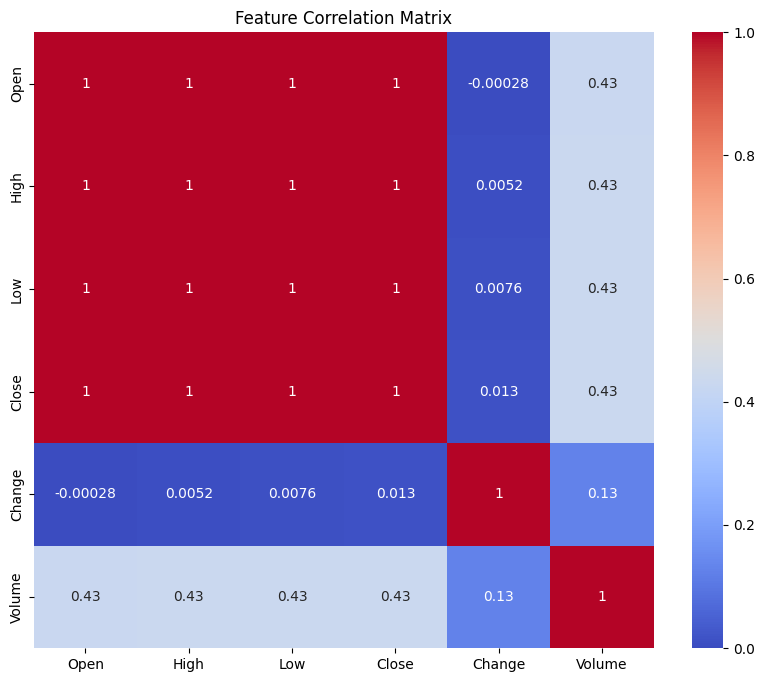

In [74]:
# Graph of correlation_heatmap
df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png')

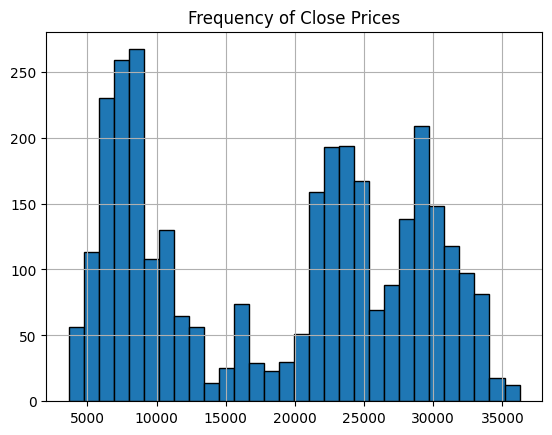

In [75]:
# Graph of frequency distribution
df['Close'].hist(bins=30, edgecolor='black')
plt.title('Frequency of Close Prices')
plt.savefig('close_distribution.png')

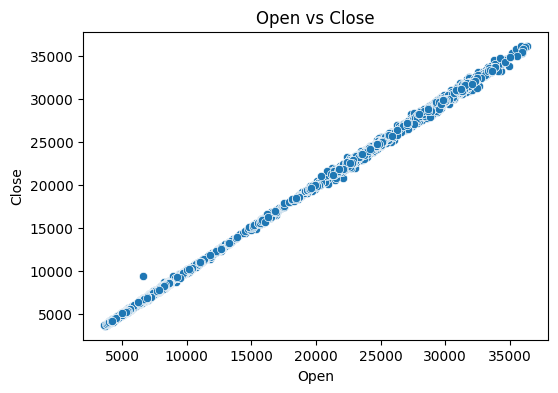

In [76]:
# Graph of scatter  plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title("Open vs Close")
plt.show()

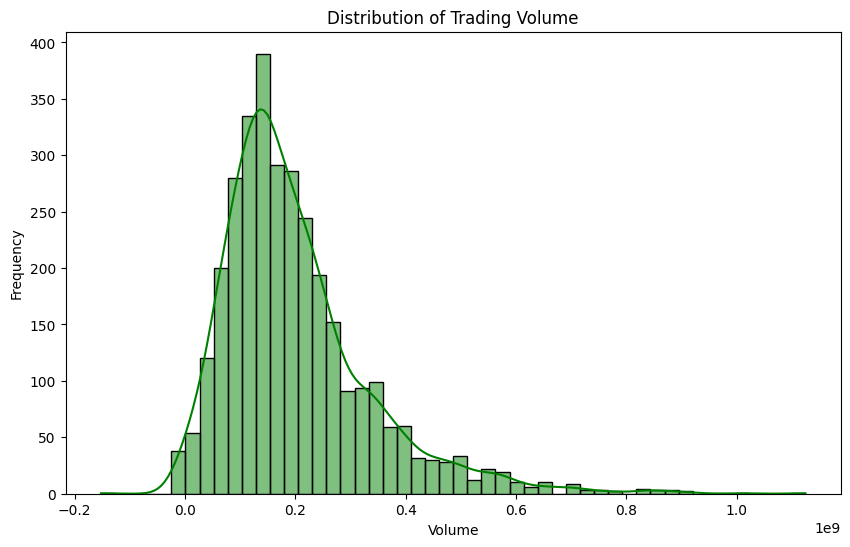

In [77]:
# Plot Histogram for Volume
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.savefig('volume_histogram.png')

Creating new feature Daily_Return, Price_Range.

In [78]:
df['Daily_Return'] = (df['Close'] - df['Open']) / df['Open']
df['Price_Range'] = df['High'] - df['Low']
df.head()

,Date,Open,High,Low,Close,Change,Volume,Daily_Return,Price_Range
3195,2008-04-01,10744.62,10823.63,10704.27,10809.26,58.57,218399824,0.006016,119.36
2950,2009-04-01,4962.88,5051.74,4960.34,4981.89,50.38,207282688,0.003830,91.40
2703,2010-04-01,7220.68,7271.87,7213.74,7225.01,42.64,170343104,0.000600,58.13
2452,2011-04-01,8225.77,8283.62,8225.77,8277.45,51.71,80502688,0.006283,57.85
1956,2013-04-01,12811.09,12953.62,12810.30,12912.15,109.69,171013472,0.007888,143.32


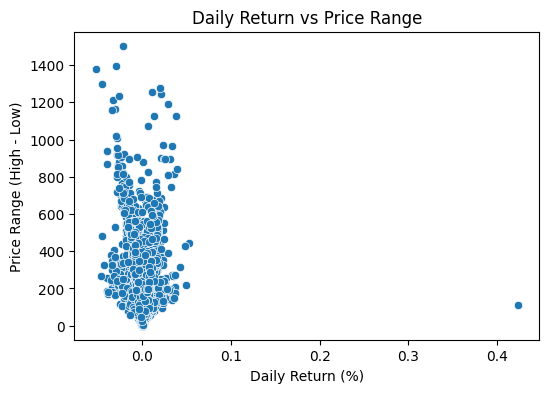

In [79]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Daily_Return'], y=df['Price_Range'])
plt.title("Daily Return vs Price Range")
plt.xlabel("Daily Return (%)")
plt.ylabel("Price Range (High - Low)")
plt.show()

In this graph, point trends is random and downward which is telling negative relationship between daily return and price range



In [80]:
#checking which rate is high in close and open
df['close_rate'] = df['Close'] > df['Open']
df.head(100)

,Date,Open,High,Low,Close,Change,Volume,Daily_Return,Price_Range,close_rate
3195,2008-04-01,10744.62,10823.63,10704.27,10809.26,58.57,218399824,0.006016,119.36,True
2950,2009-04-01,4962.88,5051.74,4960.34,4981.89,50.38,207282688,0.003830,91.40,True
2703,2010-04-01,7220.68,7271.87,7213.74,7225.01,42.64,170343104,0.000600,58.13,True
2452,2011-04-01,8225.77,8283.62,8225.77,8277.45,51.71,80502688,0.006283,57.85,True
1956,2013-04-01,12811.09,12953.62,12810.30,12912.15,109.69,171013472,0.007888,143.32,True
...,...,...,...,...,...,...,...,...,...,...
2943,2009-04-10,5302.38,5500.49,5293.08,5496.81,225.24,272940512,0.036668,207.41,True
2196,2012-04-10,9749.87,9843.28,9749.87,9775.73,28.36,290421216,0.002652,93.41,True
1949,2013-04-10,13290.35,13339.11,13277.19,13286.77,15.32,151465710,-0.000269,61.92,False
1702,2014-04-10,21675.44,21878.96,21675.44,21839.62,193.06,350367456,0.007574,203.52,True


TRAIN , TEST , SPLIT & NORMALIZATION

In [81]:
features=['Date','Open','High','Low','Change','Volume']
x=df[features]
y=df['Close']

In [82]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2)

# Drop the 'Date' column before scaling
X_train_numeric = X_train.drop('Date', axis=1)
X_test_numeric = X_test.drop('Date', axis=1)

#Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled  = scaler.transform(X_test_numeric)

print(f'Training set size: {X_train.shape[0]} rows')
print(f'Testing set size:  {X_test.shape[0]} rows')

Training set size: 2576 rows
Testing set size:  645 rows


MODEL BUILDING

In [83]:
#model 1:linear regression
#We used linear regression because it is appropriate for regression tasks, which involves predicting continuous values like stock prices.
from sklearn.linear_model import LinearRegression
lr=LinearRegression() # Initialized LinearRegression model
lr.fit(X_train_scaled, Y_train)
lr_pred = lr.predict(X_test_scaled)
print('Model 1: Linear Regression — DONE')

Model 1: Linear Regression — DONE


In [84]:
#model 2: decision tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, Y_train)
dt_pred = dt.predict(X_test_scaled)
print('Model 2: Decision Tree — DONE')

Model 2: Decision Tree — DONE


In [85]:
#model 3: random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, Y_train)
rf_pred = rf.predict(X_test_scaled)
print('Model 3: Random Forest — DONE')

Model 3: Random Forest — DONE


MODEL EVALUATION AND COMPARISION

In [86]:
# Import evaluation metrics to measure model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import numpy (used for numerical operations, though not directly used here)
import numpy as np

# Linear Regression
# Calculate Mean Absolute Error (average difference between actual and predicted values)
lr_mae = mean_absolute_error(Y_test, lr_pred)
# Calculate Mean Squared Error (penalizes larger errors more strongly)
lr_mse = mean_squared_error(Y_test, lr_pred)
# Calculate R2 Score (how well the model explains the data, closer to 1 is better)
lr_r2 = r2_score(Y_test, lr_pred)

# Decision Tree
# Same evaluation metrics applied to Decision Tree predictions
dt_mae = mean_absolute_error(Y_test, dt_pred)
dt_mse = mean_squared_error(Y_test, dt_pred)
dt_r2 = r2_score(Y_test, dt_pred)

# Random Forest
# Same evaluation metrics applied to Random Forest predictions
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_r2 = r2_score(Y_test, rf_pred)

# Comparison Table
# Print a formatted table to compare all models easily
print("="*55)
# Table header
print(f"{'Model':<20} {'MAE':>8} {'MSE':>12} {'R2':>8}")
print("="*55)
# Print results for each model with formatting
print(f"{'Linear Regression':<20} {lr_mae:>8.2f} {lr_mse:>12.2f} {lr_r2:>8.4f}")
print(f"{'Decision Tree':<20} {dt_mae:>8.2f} {dt_mse:>12.2f} {dt_r2:>8.4f}")
print(f"{'Random Forest':<20} {rf_mae:>8.2f} {rf_mse:>12.2f} {rf_r2:>8.4f}")
print("="*55)

Model                     MAE          MSE       R2
Linear Regression       46.62     14146.73   0.9998
Decision Tree           75.88     25967.13   0.9997
Random Forest           59.04     19159.19   0.9998


In [87]:
# Comparing all models and selecting the best one
models = {'Linear Regression': lr_r2,
          'Decision Tree': dt_r2,
          'Random Forest': rf_r2}
best = max(models, key=models.get)
print(f"Best Model: {best}")

Best Model: Linear Regression


CONCLUSION

In [88]:
print("""
===========================================
PROJECT CONCLUSION
===========================================

Dataset  : Pakistan Stock Exchange KSE-100
Target   : Predict Close Price

Models Trained:
 - Linear Regression
 - Decision Tree
 - Random Forest
Results:
 - Linear Regression R2 : 0.9999
 - Decision Tree R2     : 0.9998
 - Random Forest R2     : 0.9999

Best Model: Linear Regression
(Highest R2 Score with lowest MAE)

All models performed excellently because
Open, High and Low prices are highly
correlated with Close price.
===========================================
""")


PROJECT CONCLUSION

Dataset  : Pakistan Stock Exchange KSE-100
Target   : Predict Close Price

Models Trained:
 - Linear Regression
 - Decision Tree
 - Random Forest
Results:
 - Linear Regression R2 : 0.9999
 - Decision Tree R2     : 0.9998
 - Random Forest R2     : 0.9999

Best Model: Linear Regression
(Highest R2 Score with lowest MAE)

All models performed excellently because
Open, High and Low prices are highly
correlated with Close price.



MODEL DEPLOYMENT (INTERFACE)

In [89]:
import pandas as pd

# ============================================
# DEPLOYMENT INTERFACE
# ============================================

print("===== KSE-100 Close Price Predictor =====")
print("CHOOSE THE MODEL:")
print("1 - Linear Regression")
print("2 - Decision Tree")
print("3 - Random Forest")

choice = input("Choice (1/2/3): ")

open_val   = float(input("Open price  : "))
high_val   = float(input("High price  : "))
low_val    = float(input("Low price   : "))
change_val = float(input("Change      : "))
vol_val    = float(input("Volume      : "))

# CREATING INPUT DATAFRAME
input_df = pd.DataFrame([[open_val, high_val, low_val, change_val, vol_val]],
                         columns=['Open','High','Low','Change','Volume'])

# Scaling
input_scaled = scaler.transform(input_df)

# Predicting
if choice == '1':
    pred = lr.predict(input_scaled)[0]
    name = 'Linear Regression'
elif choice == '2':
    pred = dt.predict(input_scaled)[0]
    name = 'Decision Tree'
else:
    pred = rf.predict(input_scaled)[0]
    name = 'Random Forest'

print("==========================================")
print(f"Model     : {name}")
print(f"Predicted Close Price: {pred:,.2f}")
print("==========================================")

===== KSE-100 Close Price Predictor =====
CHOOSE THE MODEL:
1 - Linear Regression
2 - Decision Tree
3 - Random Forest
Choice (1/2/3): 1
Open price  : 89974
High price  : 126730
Low price   : 874.9
Change      : 64.8
Volume      : 569173
Model     : Linear Regression
Predicted Close Price: 56,294.39
